# Newsvendor Tutorial

In [1]:
import cvxpy as cp
import scipy as sc
import numpy as np
import numpy.random as npr
import torch
from sklearn import datasets
import pandas as pd
import lropt
import sys
sys.path.append('..')
from utils import plot_tradeoff,plot_iters, plot_contours, plot_contours_line
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings("ignore")
plt.rcParams.update({
    "text.usetex":True,
    
    "font.size":24,
    "font.family": "serif"
})

### Example 1: Intro example, max of affine uncertainty
We consider a problem with max of affine uncertainty, 

$$g(u,x) = \max_{l=1,\dots,L} (P_lu + a_l)^Tx,$$
where $P_l$ and $a_l$ are constants for all $l = 1, \dots, L$. The robust formulation is 
$$
\begin{array}{ll}
\text{minimize} & \tau\\
\text{subject to}  & \max_{l=1,\dots,L} (P_lu + a_l)^Tx  \leq  \tau \quad \forall u \in \mathcal{U}(\theta)\\
& x \geq 0,
\end{array}
$$


where $\theta$ encodes the training parameters $(A,b)$.

We formulate the Newsvendor problem with this framework, where we solve
\begin{equation}
	\begin{array}{ll}
		\text{minimize} & \tau\\
		\text{subject to} & k^Tx  + \max\{-p^Tx,- p^Tu\} \le \tau \quad \forall u \in \mathcal{U}(\theta) \\
		& x \geq 0.
	\end{array}
\end{equation}

In [2]:
# Formulate constants
n = 2
N = 5000
test_perc = 0.99
# k = npr.uniform(1,4,n)
# p = k + npr.uniform(2,5,n)
k = np.array([4.,5.])
p = np.array([5,6.5])
# k_tch = torch.tensor(k, requires_grad = True)
# p_tch = torch.tensor(p, requires_grad = True)

def gen_demand_intro(N, seed):
    np.random.seed(seed)
    sig = np.array([[0.6,-0.4],[-0.3,0.1]])
    mu = np.array((0.9,0.7))
    norms = np.random.multivariate_normal(mu,sig, N)
    d_train = np.exp(norms)
    return d_train


# Generate data
data = gen_demand_intro(N, seed=5)

In [3]:
num_scenarios = 5
p_data = p + np.random.normal(0,1,(num_scenarios,n))
k_data = k + np.random.normal(0,1,(num_scenarios,n))

In [4]:
# Formulate uncertainty set
u = lropt.UncertainParameter(n,
                        uncertainty_set=lropt.Ellipsoidal(
                                                    data=data))
# Formulate the Robust Problem
x_r = cp.Variable(n)
t = cp.Variable()
k = lropt.Parameter(2, data=k_data)
p = lropt.Parameter(2, data=p_data)

objective = cp.Minimize(t)

constraints = [cp.maximum(k@x_r - p@x_r, k@x_r - p@u) <= t]
constraints += [x_r >= 0]

def f_tch(t,x_r,k,p,u):
    return t
def g_tch(t,x_r,k,p,u):
    return torch.maximum(k@x_r - p@x_r, k@x_r - p@u) - t



prob = lropt.RobustProblem(objective, constraints, f_tch, [g_tch])
target = -0.1
s = 13


# setup intial A, b
train, test = train_test_split(data, test_size=int(data.shape[0]*test_perc), random_state=s)
init = sc.linalg.sqrtm(sc.linalg.inv(np.cov(train.T)))
init_bval = -init@np.mean(train, axis=0)

# Train A and b
result1 = prob.train(lr = 0.0007, step=8, momentum = 0.8, optimizer = "SGD", seed = s, init_A = init, init_b = init_bval, fixb = False, init_lam = 0, init_alpha = -0.1, test_percentage = test_perc, save_iters= True)
df1 = result1.df
A_fin = result1.A
b_fin = result1.b



In [5]:
result3 = prob.train(eps = True, lr = 0.001, step=5, momentum = 0.8, optimizer = "SGD", seed = s, init_A = init, init_b = init_bval, init_lam = 0, init_alpha  =-0.1, test_percentage = test_perc)
df_r2 = result3.df

RuntimeError: Trying to backward through the graph a second time (or directly access saved tensors after they have already been freed). Saved intermediate values of the graph are freed when you call .backward() or autograd.grad(). Specify retain_graph=True if you need to backward through the graph a second time or if you need to access saved tensors after calling backward.

In [5]:
# Grid search standard
result4 = prob.grid(epslst = np.linspace(0.01, 2.98, 100), init_A = result3.A, init_b = result3.b, seed = s, init_alpha = -0., test_percentage = test_perc,scenarios = scenarios, num_scenarios = num_scenarios)
dfgrid = result4.df

# Grid search reshaped
result5 = prob.grid(epslst = np.linspace(0.01, 2.98, 100), init_A = A_fin, init_b = b_fin, seed = s, init_alpha = -0., test_percentage = test_perc)
dfgrid2 = result5.df

In [6]:
epslst = np.linspace(0.01, 2.98, 100)
prob_list = np.array([0.,0.01,0.05,0.1])
inds_standard = []
inds_reshaped = []
for i in prob_list:
    # inds_standard.append(np.absolute(np.mean(np.vstack(dfgrid['Violations']),axis = 1)-i).argmin())
    inds_reshaped.append(np.absolute(np.mean(np.vstack(dfgrid2['Violations']),axis = 1)-i).argmin())

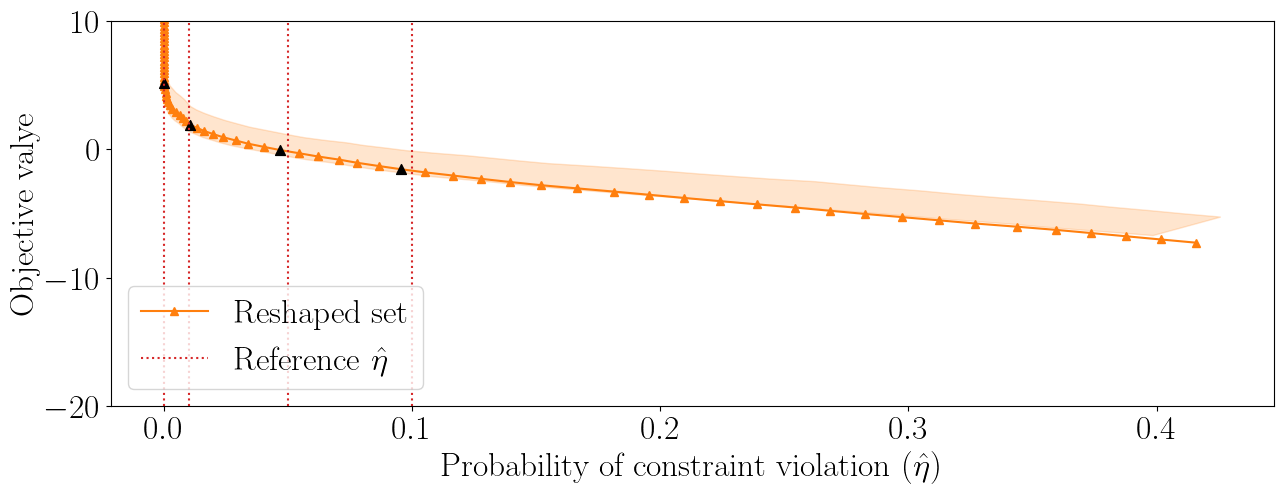

In [7]:
# eps_list = np.linspace(0.01, 2.98, 40)
# inds = [13,8,6,5]
# inds = [20,13,10,7]
eps_list = np.linspace(0.01, 2.98, 80)

plt.figure(figsize=(15, 5))
# plt.plot(np.mean(np.vstack(dfgrid['Violations']),axis = 1)[:], np.mean(np.vstack(dfgrid['Test_val']),axis = 1)[:], color="tab:blue", label=r"Standard set", marker = "v",zorder=0)
# plt.fill(np.append(np.quantile(np.vstack(dfgrid['Violations']),0.25,axis = 1),np.quantile(np.vstack(dfgrid['Violations']),0.75,axis = 1)[::-1]), np.append(np.quantile(np.vstack(dfgrid['Test_val']),0.25,axis = 1),np.quantile(np.vstack(dfgrid['Test_val']),0.75,axis = 1)[::-1]), color="tab:blue", alpha=0.2)
# for ind in range(4):
#     plt.scatter(np.mean(np.vstack(dfgrid['Violations']),axis = 1)[inds_standard[ind]],np.mean(np.vstack(dfgrid['Test_val']),axis = 1)[inds_standard[ind]], color="tab:green", s = 50, marker = "v",zorder= 10)
#     # plt.annotate(r"$\epsilon$ = {}".format(round(eps_list[inds_standard[ind]],2)), # this is the text
#     #               (np.mean(np.vstack(dfgrid['Violations']),axis = 1)[inds_standard[ind]],np.mean(np.vstack(dfgrid['Test_val']),axis = 1)[inds_standard[ind]]), # these are the coordinates to position the label
#     #               textcoords="offset points", # how to position the text
#     #               xytext=(5,3), # distance from text to points (x,y)
#     #               ha='left',color="tab:green",fontsize=15) 

plt.plot(np.mean(np.vstack(dfgrid2['Violations']),axis = 1),np.mean(np.vstack(dfgrid2['Test_val']),axis = 1), color="tab:orange", label="Reshaped set", marker = "^",zorder=1)
plt.fill(np.append(np.quantile(np.vstack(dfgrid2['Violations']),0.25,axis = 1),np.quantile(np.vstack(dfgrid2['Violations']),0.75,axis = 1)[::-1]), np.append(np.quantile(np.vstack(dfgrid2['Test_val']),0.25,axis = 1),np.quantile(np.vstack(dfgrid2['Test_val']),0.75,axis = 1)[::-1]), color="tab:orange", alpha=0.2)
for ind in [0,2,1,3]:
    plt.scatter(np.mean(np.vstack(dfgrid2['Violations']),axis = 1)[inds_reshaped[ind]],np.mean(np.vstack(dfgrid2['Test_val']),axis = 1)[inds_reshaped[ind]], color="black", s = 50, marker = "^")
    # plt.annotate(r"$\epsilon$ = {}".format(round(eps_list[inds_reshaped[ind]],2)), # this is the text
    #               (np.mean(np.vstack(dfgrid2['Violations']),axis = 1)[inds_reshaped[ind]],np.mean(np.vstack(dfgrid2['Test_val']),axis = 1)[inds_reshaped[ind]]), # these are the coordinates to position the label
    #               textcoords="offset points", # how to position the text
    #               xytext=(5,1), # distance from text to points (x,y)
    #               ha='left',color="black", fontsize = 15) 
plt.ylabel("Objective valye")
# ax2.set_xlim([-1,20])
plt.xlabel(r"Probability of constraint violation $(\hat{\eta})$")
#plt.xscale("log")
plt.ylim([-20,10])
plt.vlines(ymin = -20, ymax= 10, x = prob_list[0], linestyles=":", color = "tab:red", label = "Reference $\hat{\eta}$")
for i in prob_list[1:]:
    plt.vlines(ymin = -20, ymax= 10, x = i, linestyles=":", color = "tab:red")

plt.legend()
# lgd = plt.legend(loc = "lower right", bbox_to_anchor=(1.5, 0.3))
plt.savefig("ex1_curves_orig.pdf", bbox_inches='tight')
# plt.savefig("ex1_curves1.pdf", bbox_extra_artists=(lgd,), bbox_inches='tight')


In [8]:
plt.figure(figsize=(10, 5))
plt.plot(np.mean(np.vstack(dfgrid['Violation_val']),axis = 1)[:], np.mean(np.vstack(dfgrid['Test_val']),axis = 1)[:], color="tab:blue", label=r"Standard set", marker = "v",zorder=0)
plt.fill(np.append(np.quantile(np.vstack(dfgrid['Violation_val']),0.1,axis = 1),np.quantile(np.vstack(dfgrid['Violation_val']),0.9,axis = 1)[::-1]), np.append(np.quantile(np.vstack(dfgrid['Test_val']),0.1,axis = 1),np.quantile(np.vstack(dfgrid['Test_val']),0.90,axis = 1)[::-1]), color="tab:blue", alpha=0.2)
for ind in range(4):
    plt.scatter(np.mean(np.vstack(dfgrid['Violation_val']),axis = 1)[inds_standard[ind]],np.mean(np.vstack(dfgrid['Test_val']),axis = 1)[inds_standard[ind]], color="tab:green", s = 50, marker = "v",zorder= 10)
    plt.annotate(r"$\epsilon$ = {}".format(round(eps_list[inds_standard[ind]],2)), # this is the text
                  (np.mean(np.vstack(dfgrid['Violation_val']),axis = 1)[inds_standard[ind]],np.mean(np.vstack(dfgrid['Test_val']),axis = 1)[inds_standard[ind]]), # these are the coordinates to position the label
                  textcoords="offset points", # how to position the text
                  xytext=(5,3), # distance from text to points (x,y)
                  ha='left',color="tab:green",fontsize=15) 

plt.plot(np.mean(np.vstack(dfgrid2['Violation_val']),axis = 1),np.mean(np.vstack(dfgrid2['Test_val']),axis = 1), color="tab:orange", label="Reshaped set", marker = "^",zorder=1)
plt.fill(np.append(np.quantile(np.vstack(dfgrid2['Violation_val']),0.1,axis = 1),np.quantile(np.vstack(dfgrid2['Violation_val']),0.9,axis = 1)[::-1]), np.append(np.quantile(np.vstack(dfgrid2['Test_val']),0.1,axis = 1),np.quantile(np.vstack(dfgrid2['Test_val']),0.90,axis = 1)[::-1]), color="tab:orange", alpha=0.2)
for ind in [1,3]:
    plt.scatter(np.mean(np.vstack(dfgrid2['Violation_val']),axis = 1)[inds_reshaped[ind]],np.mean(np.vstack(dfgrid2['Test_val']),axis = 1)[inds_reshaped[ind]], color="black", s = 50, marker = "^")
    plt.annotate(r"$\epsilon$ = {}".format(round(eps_list[inds_reshaped[ind]],2)), # this is the text
                  (np.mean(np.vstack(dfgrid2['Violation_val']),axis = 1)[inds_reshaped[ind]],np.mean(np.vstack(dfgrid2['Test_val']),axis = 1)[inds_reshaped[ind]]), # these are the coordinates to position the label
                  textcoords="offset points", # how to position the text
                  xytext=(5,1), # distance from text to points (x,y)
                  ha='left',color="black", fontsize = 15) 
plt.ylabel("Objective valye")
# ax2.set_xlim([-1,20])
# plt.ylim([-50,70])
plt.xlabel("Empirical $\mathbf{CVaR}$")
plt.legend()
# lgd = plt.legend(loc = "lower right", bbox_to_anchor=(1.5, 0.3))
plt.savefig("ex1_cvar.pdf", bbox_inches='tight')
# plt.savefig("ex1_curves1.pdf", bbox_extra_artists=(lgd,), bbox_inches='tight')


NameError: name 'dfgrid' is not defined

<Figure size 1000x500 with 0 Axes>

In [11]:
k = np.array([4.,5.])
p = np.array([5,6.5])
x_opt_base = {}
x_opt_learned = {}
t_learned = {}
t_base = {}
for ind in range(4):
    x_opt_base[ind] = {}
    x_opt_learned[ind] = {}
    t_learned[ind] = {}
    t_base[ind] = {}
    for scene in range(num_scenarios):
        n = 2
        u = lropt.UncertainParameter(n,
                                uncertainty_set=lropt.Ellipsoidal(p=2,
                                                            A = (1/eps_list[inds_standard[ind]])*result3.A, b = (1/eps_list[inds_standard[ind]])*result3.b))
        # Formulate the Robust Problem
        x_r = cp.Variable(n)
        t = cp.Variable()
        k = scenarios[scene][0]
        p = scenarios[scene][1]
        # y = cp.Variable()

        objective = cp.Minimize(t)

        constraints = [cp.maximum(k@x_r - p@x_r, k@x_r - p@u) <= t]
        # constraints += [cp.maximum(k1@(x_r-u),0) <= y]
        # constraints = [cp.maximum(u@k + k1@x_r -u@(k + k1), u@k + k1@x_r - x_r@(k + k1))<=t]

        constraints += [x_r >= 0]

        prob = lropt.RobustProblem(objective, constraints)
        prob.solve()
        # result3.reform_problem.solve()
        x_opt_base[ind][scene] = x_r.value

        t_base[ind][scene] = t.value

        n = 2
        u = lropt.UncertainParameter(n,
                                uncertainty_set=lropt.Ellipsoidal(p=2,
                                                            A = (1/eps_list[inds_reshaped[ind]])*A_fin, b = (1/eps_list[inds_reshaped[ind]])*b_fin))
        # Formulate the Robust Problem
        x_r = cp.Variable(n)
        t = cp.Variable()
        k = scenarios[scene][0]
        p = scenarios[scene][1]
        # y = cp.Variable()

        objective = cp.Minimize(t)

        constraints = [cp.maximum(k@x_r - p@x_r, k@x_r - p@u) <= t]
        # constraints += [cp.maximum(k1@(x_r-u),0) <= y]
        # constraints = [cp.maximum(u@k + k1@x_r -u@(k + k1), u@k + k1@x_r - x_r@(k + k1))<=t]

        constraints += [x_r >= 0]

        prob = lropt.RobustProblem(objective, constraints)
        prob.solve()
        # result3.reform_problem.solve()
        x_opt_learned[ind][scene] = x_r.value

        t_learned[ind][scene] = t.value
        x_opt_learned,x_opt_base,t_learned, t_base
    # A_fin, init, b_fin, init_bval
# x_opt_learned,x_opt_base,t_learned, t_base
A_fin, b_fin, init, init_bval

(array([[ 0.82954895, -0.11598049],
        [ 0.32090367,  0.97351911]]),
 array([-1.87099873, -2.8163914 ]),
 array([[0.35029562, 0.15733994],
        [0.15733994, 1.03055715]]),
 array([-1.65405866, -2.63233048]))

In [18]:
type(x_opt_learned)

dict

In [12]:
K =1
num_p = 50
offset = 2
x_min, x_max = np.min(train[:,0]) - offset, np.max(train[:,0]) + offset
y_min, y_max = np.min(train[:,1]) - offset, np.max(train[:,1]) + offset
X = np.linspace(x_min,x_max,num_p)
Y = np.linspace(y_min,y_max,num_p)
x,y = np.meshgrid(X,Y)
# Z values as a matrix
fin_set = {}
init_set = {}
for ind in range(4):
    fin_set[ind] = {}
    init_set[ind] = {}
    for k_ind in range(K):
        fin_set[ind][k_ind] = np.zeros((num_p,num_p))
        init_set[ind][k_ind] = np.zeros((num_p,num_p))
g_level_learned = {}
g_level_base = {}
for ind in range(4):
    g_level_learned[ind] = {}
    g_level_base[ind] = {}
    for scene in range(num_scenarios):
        g_level_learned[ind][scene] = np.zeros((num_p,num_p))
        g_level_base[ind][scene] = np.zeros((num_p,num_p))
# init_set = np.zeros((num_p,num_p))
    # Populate Z Values (a 7x7 matrix) - For a circle x^2+y^2=z
    for i in range(num_p):
        for j in range(num_p):
            u_vec = [x[i,j], y[i,j]]
            for k_ind in range(K):
                fin_set[ind][k_ind][i,j] = np.linalg.norm((1/eps_list[inds_reshaped[ind]])*A_fin[k_ind*n:(k_ind+1)*n, 0:n]@ u_vec + (1/eps_list[inds_reshaped[ind]])*b_fin)

            for k_ind in range(K):
                init_set[ind][k_ind][i,j] = np.linalg.norm((1/eps_list[inds_standard[ind]])*result3.A[k_ind*n:(k_ind+1)*n, 0:n]@ u_vec  + (1/eps_list[inds_standard[ind]])*result3.b)
            
            for scene in range(num_scenarios):
                g_level_learned[ind][scene][i,j] = np.maximum(scenarios[scene][0] @ x_opt_learned[ind][scene] - scenarios[scene][1] @ x_opt_learned[ind][scene], scenarios[scene][0] @ x_opt_learned[ind][scene] - scenarios[scene][1] @ u_vec) - t_learned[ind][scene]
                g_level_base[ind][scene][i,j] = np.maximum(scenarios[scene][0] @ x_opt_base[ind][scene] - scenarios[scene][1] @ x_opt_base[ind][scene], scenarios[scene][0] @ x_opt_base[ind][scene] - scenarios[scene][1] @ u_vec) - t_base[ind][scene]

{0: {0: array([3.66808802, 4.88129797]), 1: array([5.66831677, 7.48596312])},
 1: {0: array([3.74397961, 2.10370493]), 1: array([6.84330456, 4.97434971])},
 2: {0: array([4.20319161, 4.83259129]), 1: array([6.78500109, 7.8542465 ])},
 3: {0: array([5.86811936, 4.188929  ]), 1: array([9.81348808, 7.61856098])},
 4: {0: array([2.88797268, 5.48292922]), 1: array([5.301411  , 9.32015104])},
 5: {0: array([5.57144061, 3.32791922]), 1: array([9.21389885, 5.41131247])},
 6: {0: array([2.30523316, 5.11967517]), 1: array([5.18205162, 8.56660552])},
 7: {0: array([5.49371761, 5.87416265]), 1: array([9.23210669, 8.93587403])}}

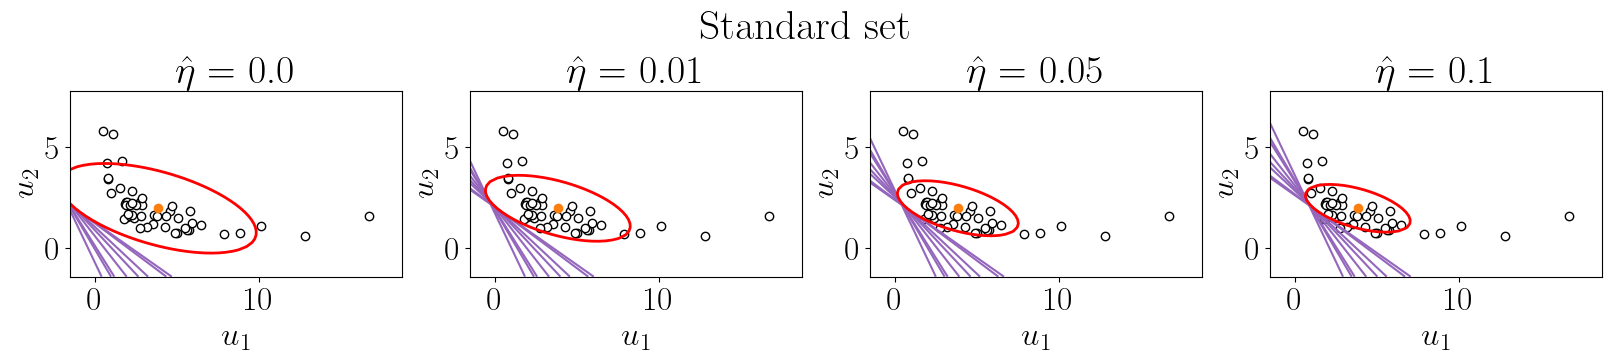

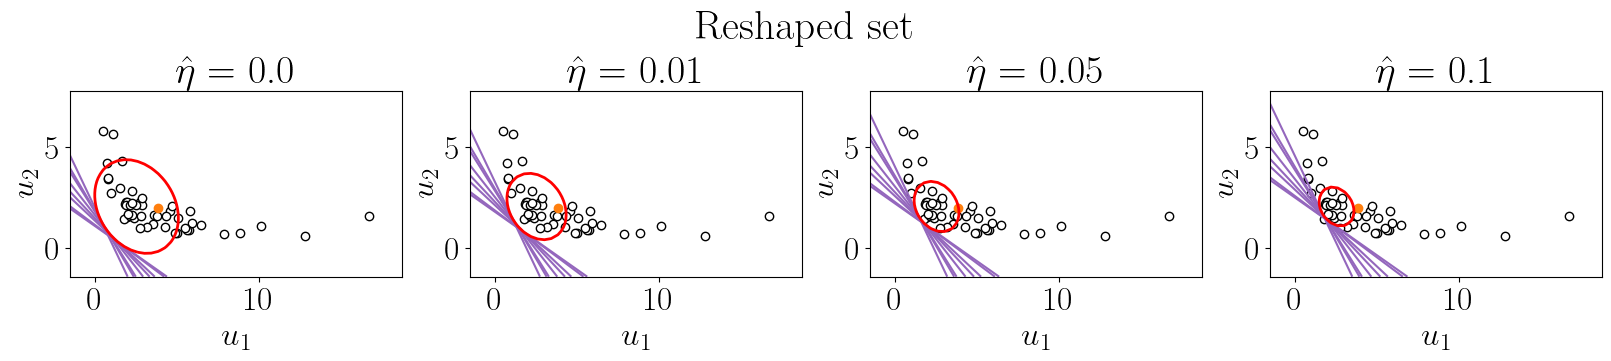

In [13]:
plot_contours_line(x,y,init_set, g_level_base,prob_list,num_scenarios,train, "news_intro",standard = True) 
plot_contours_line(x,y,fin_set, g_level_learned,prob_list,num_scenarios,train, "news_intro",standard = False)

## GIF

In [34]:
A_fin = result1.A
b_fin = result1.b
A1_iters, b1_iters = result1.uncset_iters

In [35]:
def newsvendor_prob(A_final, b_final, scene):
    n = 2
    u = lropt.UncertainParameter(n,uncertainty_set=lropt.Ellipsoidal(p=2, A = A_final, b = b_final))
    # Formulate the Robust Problem
    x_r = cp.Variable(n)
    t = cp.Variable()
    k = scenarios[scene][0]
    p = scenarios[scene][1]
    # y = cp.Variable()

    objective = cp.Minimize(t)

    constraints = [cp.maximum(k@x_r - p@x_r, k@x_r - p@u) <= t]
    # constraints += [cp.maximum(k1@(x_r-u),0) <= y]
    # constraints = [cp.maximum(u@k + k1@x_r -u@(k + k1), u@k + k1@x_r - x_r@(k + k1))<=t]

    constraints += [x_r >= 0]

    prob = lropt.RobustProblem(objective, constraints)
    prob.solve()
    t_opt = t.value
    x_opt = x_r.value

    return x_opt, t_opt

In [36]:
offset = 1
x_min, x_max = np.min(train[:,0]) - 3*offset, np.max(train[:,0]) + offset
y_min, y_max = np.min(train[:,1]) - offset, np.max(train[:,1]) + offset
n_points = 100
X = np.linspace(x_min,x_max,n_points)
Y = np.linspace(y_min,y_max,n_points)
x_mesh,y_mesh = np.meshgrid(X,Y)

def optimal_sols(A_final, b_final, num_scenarios):
    x_opt = {}
    t_opt = {}
    for scene in range(num_scenarios):
        x_opt[scene], t_opt[scene] = newsvendor_prob(A_final, b_final, scene)
    return x_opt, t_opt

def level_set(A_final, b_final, offset = 2, n = n_points, x_mesh = x_mesh, y_mesh = y_mesh):
    unc_level_set = np.zeros((n,n))
    g_level_set = np.zeros((num_scenarios,n,n))
    x_opt,t_opt = optimal_sols(A_final, b_final, num_scenarios)
    for i in range(n):
        for j in range(n):
            u_vec = [x_mesh[i,j], y_mesh[i,j]]
            unc_level_set[i,j] = np.linalg.norm(A_final @ u_vec  + b_final)
            for scene in range(num_scenarios):
                g_level_set[scene,i,j] = np.maximum(scenarios[scene][0] @ x_opt[scene] - scenarios[scene][1] @ x_opt[scene], scenarios[scene][0] @ x_opt[scene] - scenarios[scene][1] @ u_vec) - t_opt[scene]

    return unc_level_set, g_level_set

In [37]:
unc_level_learned, g_level_learned = level_set(A_fin, b_fin)
unc_level_base, g_level_base = level_set(init, init_bval)

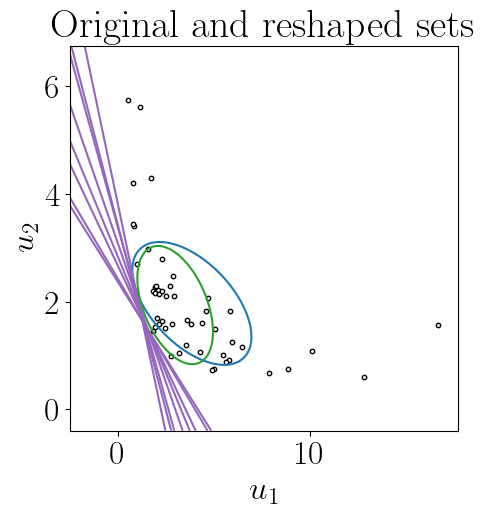

In [38]:
plt.figure(figsize=(5, 5))
plt.title("Original and reshaped sets")
# Set axis label for the contour plot
plt.xlabel(r"$u_1$")
plt.ylabel(r"$u_2$")

plt.contour(x_mesh,y_mesh,unc_level_base, [1], colors = ["tab:blue"], label = "Initial Set")
plt.contour(x_mesh,y_mesh,unc_level_learned, [1], colors = ["tab:green"], label = "Final Set")
for scene in range(num_scenarios):
    plt.contour(x_mesh,y_mesh,g_level_learned[scene,:,:], [1], colors = ["tab:purple"], label = "Initial Set")
    # plt.contour(x_mesh,y_mesh,g_level_base[scene,:,:], [1], colors = ["tab:green"], label = "Final Set")

plt.scatter(train[:,0],train[:,1], color = "white",edgecolors= "black", s = 10)
# plt.savefig("Reshaped_ctrs.pdf", bbox_inches='tight')
plt.show()

In [41]:
import os
import imageio

filenames = []
for i in range(len(A1_iters)):
    # 
    unc_level, g_level = level_set(A1_iters[i], b1_iters[i])
    plt.figure(figsize=(5, 5))
    plt.title("Original and reshaped sets")
    # Set axis label for the contour plot
    plt.xlabel(r"$u_1$")
    plt.ylabel(r"$u_2$")

    plt.contour(x_mesh,y_mesh,unc_level_base, [1], colors = ["tab:blue"], label = "Initial Set")
    plt.contour(x_mesh,y_mesh,unc_level, [1], colors = ["tab:red"], label = "trained Set")
    plt.contour(x_mesh,y_mesh,unc_level_learned, [1], colors = ["tab:green"], label = "Final Set")
    for scene in range(num_scenarios):
        plt.contour(x_mesh,y_mesh,g_level[scene,:,:], [1], colors = ["tab:purple"], label = "Initial Set")

    filename = f'gif_images/{i}.png'
    filenames.append(filename)

    plt.scatter(train[:,0],train[:,1], color = "white",edgecolors= "black", s = 10)
    plt.savefig(filename)
    plt.close()

with imageio.get_writer('gifs/newsvendor.gif', mode='I') as writer:
    for filename in filenames:
        image = imageio.imread(filename)
        writer.append_data(image)

In [6]:
import numpy as np
A = np.ones((8,4)) 
A[0,:] += A[0,:]
A

array([[2., 2., 2., 2.],
       [1., 1., 1., 1.],
       [1., 1., 1., 1.],
       [1., 1., 1., 1.],
       [1., 1., 1., 1.],
       [1., 1., 1., 1.],
       [1., 1., 1., 1.],
       [1., 1., 1., 1.]])

In [8]:
A-A[1,:]

array([[1., 1., 1., 1.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.]])